In [1]:
library(Seurat)
# library(SeuratDisk)

library(reticulate)
library(anndata)

library(ggplot2)
library(ggpubr)
library(pheatmap)
library(dplyr)
library(tidyr)
library(RColorBrewer)
library(clustree)
library(repr)
options(repr.plot.width=10, repr.plot.height=8)

library(UpSetR)
library(grid)

library(PRROC)
library(Matrix)

getwd()

dataset_id <- "simulated_mm_RA"
genome_id <- "mm10"
samples <- c("all")

for (sample in samples) {
    dir.create(paste0("figures_", dataset_id, "_", sample))
}

colorTools <- c(
    "STARsolo_TE" = "#FFBC81",
    "STARsolo_TE_EM" = "#F3E088",
    "SoloTE_unique" = "#A4DD9B",
    "SoloTE_thr2" = "#6FC69D",
    "SoloTE_thr1" = "#4BB2BB",
    "SoloTE_thr0" = "#3989BF",
    "Stellarscope" = "#4F5D93",
    "simulated" = "grey70"
)

thrMinCells <- 500 * 0.05

Loading required package: SeuratObject

Loading required package: sp




Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggraph


Attaching package: ‘ggraph’


The following object is masked from ‘package:sp’:

    geometry


Loading required package: rlang


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




[1] "/mnt/TEdata/TEbenchmarking/Rscripts"

Warning message in dir.create(paste0("figures_", dataset_id, "_", sample)):
“'figures_simulated_mm_RA_all' already exists”


In [2]:
# import workspace
load("workspaces/mm_RA_simulation_evaluation_objectCreation.Rdata")

In [3]:
sample <- "all"

# Evaluation

## Metrics by age

In [5]:
layer <- "counts"

matSplatter <- GetAssayData(splatter_objs[[sample]], layer=layer)

# split the matrix by age
splatter_age_vec <- conversion_table$ageClass[match(rownames(matSplatter), conversion_table$stellarscopeID)]

matSplatter_age_List <- list()
matSplatter_age_List[["old"]] <- matSplatter[splatter_age_vec=="old",]
matSplatter_age_List[["young"]] <- matSplatter[splatter_age_vec=="young",]

precisionTool_age_List <- list()
recallTool_age_List <- list()

for(age in c("old", "young")){
  
  precisionTool_age_List[[age]] <- list()
  recallTool_age_List[[age]] <- list()
  
  for(tool in names(objList)){
  
    # get matrix of the tool, keep only TEs of the right age
    matTool <- as.matrix(GetAssayData(objList[[tool]][[sample]], layer=layer))
    
    print(table(rownames(matTool) %in% conversion_table$stellarscopeID))
    
    tool_age_vec <- conversion_table$ageClass[match(rownames(matTool), conversion_table$stellarscopeID)]
    matTool <- matTool[tool_age_vec==age,]
    
    precisionTool_age_List[[age]][[tool]] <- NULL
    recallTool_age_List[[age]][[tool]] <- NULL
    
    for(cell in Cells(splatter_objs[[sample]])){
      
      exprSplatter <- names(matSplatter_age_List[[age]][,cell])[matSplatter_age_List[[age]][,cell] > 0] # TEs expressed in the simulated matrix
      
      exprTool <- names(matTool[,cell])[matTool[,cell] > 0] # TEs detected by the tool

      TP <- intersect(exprSplatter, exprTool)
      nTP <- length(TP)
      
      FP <- setdiff(exprTool, exprSplatter)
      nFP <- length(FP)
      
      FN <- setdiff(exprSplatter, exprTool)
      nFN <- length(FN)
      
      precision <- nTP / (nTP + nFP)
      precisionTool_age_List[[age]][[tool]] <- c(precisionTool_age_List[[age]][[tool]], precision)
      
      recall <- nTP / (nTP + nFN)
      recallTool_age_List[[age]][[tool]] <- c(recallTool_age_List[[age]][[tool]], recall)
      
    }
  }
}



 TRUE 
14107 

 TRUE 
34803 

TRUE 
6128 

TRUE 
8675 

 TRUE 
11686 

 TRUE 
33662 

TRUE 
6959 

 TRUE 
14107 

 TRUE 
34803 

TRUE 
6128 

TRUE 
8675 

 TRUE 
11686 

 TRUE 
33662 

TRUE 
6959 


## Plot F1 score

Saving 7 x 7 in image
Saving 7 x 7 in image


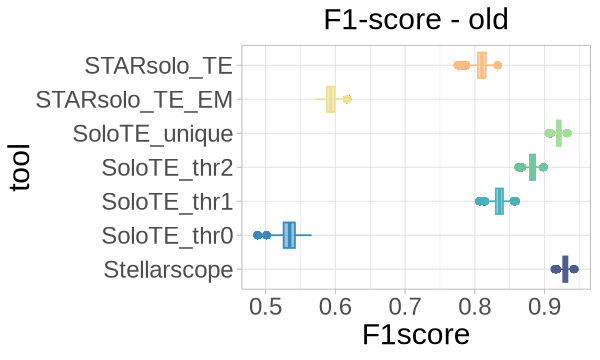

Saving 7 x 7 in image
Saving 7 x 7 in image


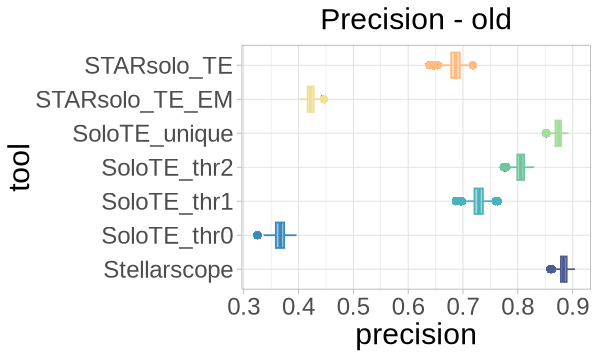

Saving 7 x 7 in image
Saving 7 x 7 in image


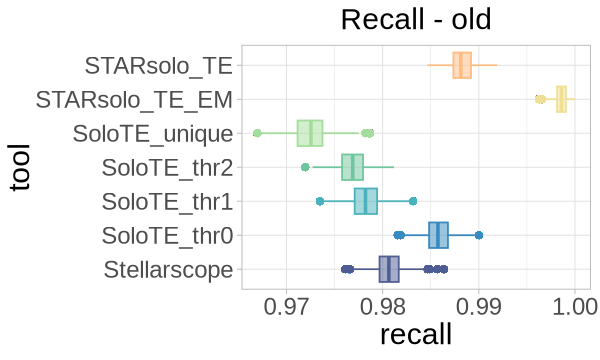

Saving 7 x 7 in image
Saving 7 x 7 in image


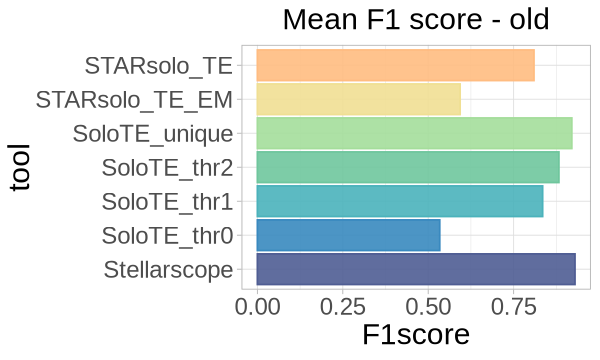

Saving 7 x 7 in image
Saving 7 x 7 in image


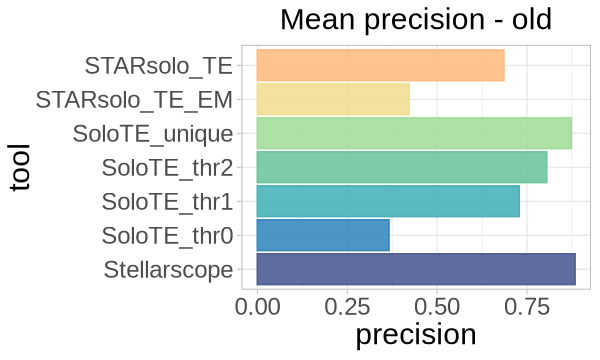

Saving 7 x 7 in image
Saving 7 x 7 in image


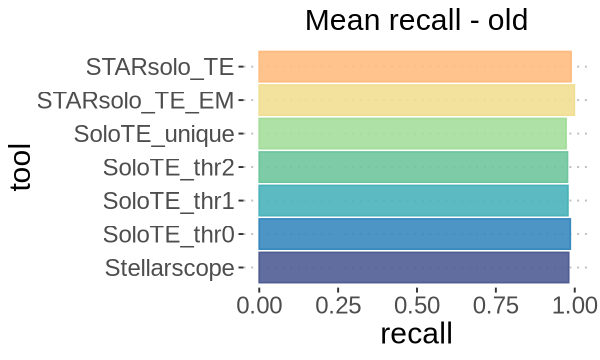

Saving 7 x 7 in image
Saving 7 x 7 in image


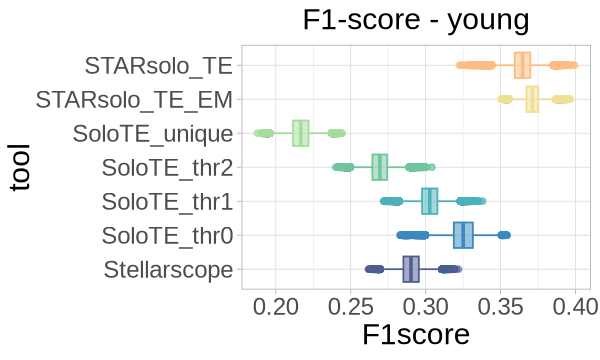

Saving 7 x 7 in image
Saving 7 x 7 in image


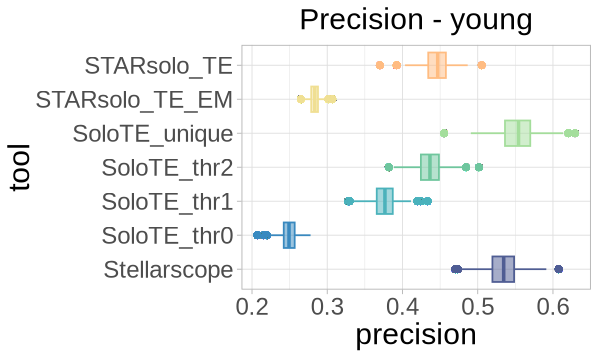

Saving 7 x 7 in image
Saving 7 x 7 in image


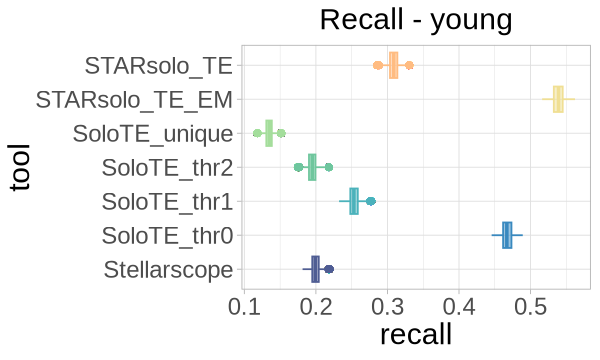

Saving 7 x 7 in image
Saving 7 x 7 in image


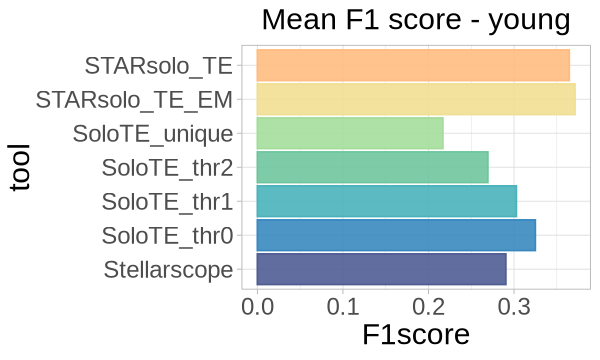

Saving 7 x 7 in image
Saving 7 x 7 in image


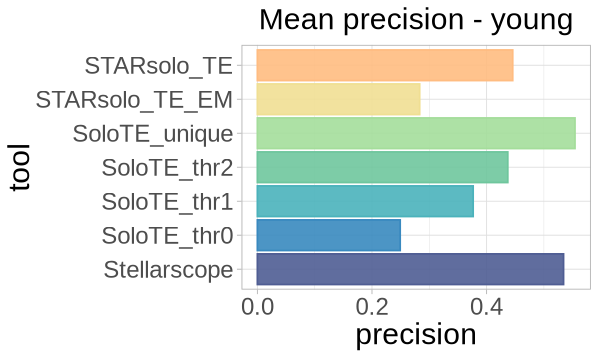

Saving 7 x 7 in image
Saving 7 x 7 in image


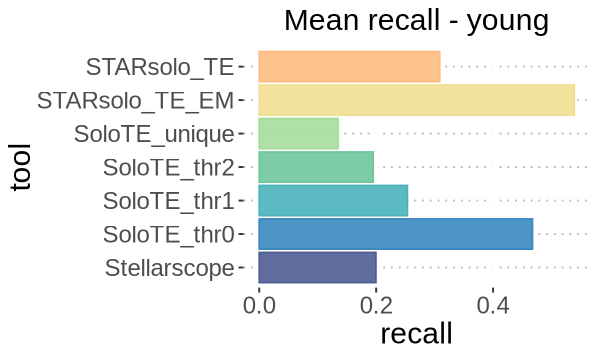

In [6]:
options(repr.plot.width=5, repr.plot.height=3)

meanF1score_age_df <- NULL

for(age in c("old", "young")){
  
  precisionDf <- stack(precisionTool_age_List[[age]])
  colnames(precisionDf) <- c("precision", "tool")
  
  
  recallDf <- stack(recallTool_age_List[[age]])
  colnames(recallDf) <- c("recall", "tool")
  
  df <- merge(precisionDf, recallDf, by='tool')
  
  df$F1score <- (2 * df$precision * df$recall) / (df$precision + df$recall)
  
  
  df$tool <- factor(df$tool, levels=rev(names(colorTools)))
  
  show(
    ggplot(df, aes(x=F1score, y=tool, color=tool, fill=tool)) +
      geom_boxplot(alpha = 0.5) + 
      scale_color_manual(values=colorTools) +
      scale_fill_manual(values=colorTools) +
      theme_light() + 
      ggtitle(paste0("F1-score - ", age)) +
      guides(fill="none", color="none") +
      theme(text=element_text(size=18), 
            plot.title = element_text(size=18, hjust=0.5), 
            plot.subtitle = element_text(size=18, hjust=0.5))
  )
  ggsave(paste0("figures_",dataset_id,"_",sample,"/F1score_tool_",age,".png"), device="png")
  ggsave(paste0("figures_",dataset_id,"_",sample,"/F1score_tool_",age,".pdf"), device="pdf")
  
  show(
    ggplot(df, aes(x=precision, y=tool, color=tool, fill=tool)) + 
      geom_boxplot(alpha = 0.5) + 
      scale_color_manual(values=colorTools) +
      scale_fill_manual(values=colorTools) +
      theme_light() + 
      ggtitle(paste0("Precision - ", age)) +
      guides(fill="none", color="none") +
      theme(text=element_text(size=18), 
            plot.title = element_text(size=18, hjust=0.5), 
            plot.subtitle = element_text(size=18, hjust=0.5))
  )
  ggsave(paste0("figures_",dataset_id,"_",sample,"/precision_tool_",age,".png"), device="png")
  ggsave(paste0("figures_",dataset_id,"_",sample,"/precision_tool_",age,".pdf"), device="pdf")
  
  show(
    ggplot(df, aes(x=recall, y=tool, color=tool, fill=tool)) + 
      geom_boxplot(alpha = 0.5) +
      scale_color_manual(values=colorTools) +
      scale_fill_manual(values=colorTools) +
      theme_light() + 
      ggtitle(paste0("Recall - ", age)) +
      guides(fill="none", color="none") +
      theme(text=element_text(size=18), 
            plot.title = element_text(size=18, hjust=0.5), 
            plot.subtitle = element_text(size=18, hjust=0.5))
  )
  ggsave(paste0("figures_",dataset_id,"_",sample,"/recall_tool_",age,".png"), device="png")
  ggsave(paste0("figures_",dataset_id,"_",sample,"/recall_tool_",age,".pdf"), device="pdf")
  
  
  # plot just the mean value
  
  precisionDf <- stack(lapply(precisionTool_age_List[[age]], mean))
  colnames(precisionDf) <- c("precision", "tool")

  recallDf <- stack(lapply(recallTool_age_List[[age]], mean))
  colnames(recallDf) <- c("recall", "tool")

  Fscores <- sapply(names(precisionTool_age_List[[age]]), function(tool){
                          (2 * precisionTool_age_List[[age]][[tool]] * recallTool_age_List[[age]][[tool]]) /
                          (precisionTool_age_List[[age]][[tool]] + recallTool_age_List[[age]][[tool]])
  })
  meanFscores <- colMeans(Fscores)
  FscoreDf <- stack(meanFscores)
  colnames(FscoreDf) <- c("F1score", "tool")

  df <- merge(precisionDf, recallDf, by=c("tool"))
  df <- merge(df, FscoreDf, by=c("tool"))

  df$tool <- factor(df$tool, levels=rev(names(colorTools)))
  
  # create df for facet plot
  meanF1score_age_df <- rbind(meanF1score_age_df, cbind(df, age)) 
  
  show(
    ggplot(df, aes(x=F1score, y=tool, color=tool, fill=tool)) +
      geom_col(alpha = 0.9) +
      scale_color_manual(values=colorTools) +
      scale_fill_manual(values=colorTools) +
      theme_light() + ggtitle(paste0("Mean F1 score - ", age))  +
      guides(fill="none", color="none") +
      theme(text=element_text(size=18),
            plot.title = element_text(size=18, hjust=0.5),
            plot.subtitle = element_text(size=18, hjust=0.5))
    )
  ggsave(paste0("figures_",dataset_id,"_",sample,"/meanF1score_tool_",age,".png"), device="png")
  ggsave(paste0("figures_",dataset_id,"_",sample,"/meanF1score_tool_",age,".pdf"), device="pdf")

  show(
    ggplot(df, aes(x=precision, y=tool, color=tool, fill=tool)) +
      geom_col(alpha = 0.9) +
      scale_color_manual(values=colorTools) +
      scale_fill_manual(values=colorTools) +
      theme_light() + ggtitle(paste0("Mean precision - ", age))  +
      guides(fill="none", color="none") +
      theme(text=element_text(size=18),
            plot.title = element_text(size=18, hjust=0.5),
            plot.subtitle = element_text(size=18, hjust=0.5))
  )
  ggsave(paste0("figures_",dataset_id,"_",sample,"/meanPrecision_tool_",age,".png"), device="png")
  ggsave(paste0("figures_",dataset_id,"_",sample,"/meanPrecision_tool_",age,".pdf"), device="pdf")

  show(
    ggplot(df, aes(x=recall, y=tool, color=tool, fill=tool)) +
      geom_col(alpha = 0.9) +
      scale_color_manual(values=colorTools) +
      scale_fill_manual(values=colorTools) +
      theme_pubclean() + ggtitle(paste0("Mean recall - ", age)) +
      guides(fill="none", color="none") +
      theme(text=element_text(size=18),
            plot.title = element_text(size=18, hjust=0.5),
            plot.subtitle = element_text(size=18, hjust=0.5))
  )
  ggsave(paste0("figures_",dataset_id,"_",sample,"/meanRecall_tool_",age,".png"), device="png")
  ggsave(paste0("figures_",dataset_id,"_",sample,"/meanRecall_tool_",age,".pdf"), device="pdf")

}

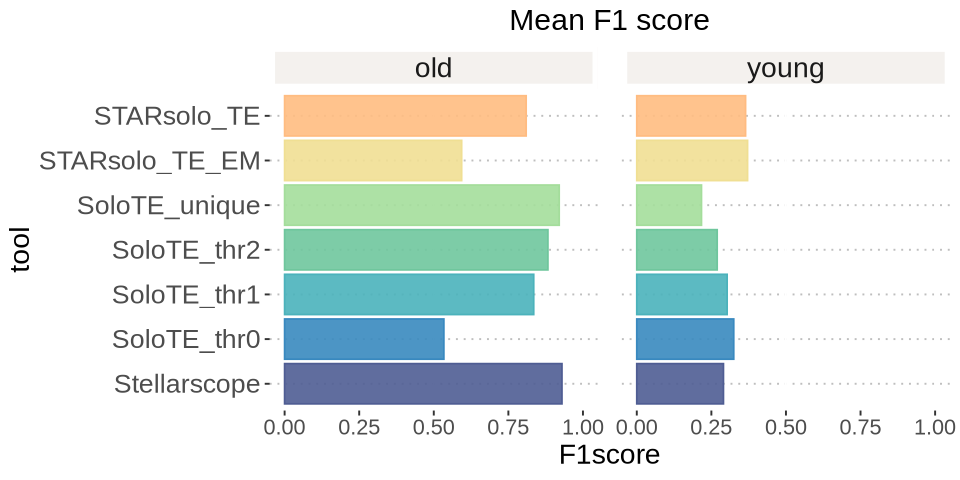

In [7]:
options(repr.plot.width=8, repr.plot.height=4)
 
ggplot(meanF1score_age_df, aes(x=F1score, y=tool, color=tool, fill=tool)) +
    facet_wrap(~age, ncol = 2) +
    geom_col(alpha = 0.9) +
    scale_color_manual(values=colorTools) +
    scale_fill_manual(values=colorTools) +
    theme_pubclean() + ggtitle(paste0("Mean F1 score")) +
    guides(fill="none", color="none") +
  xlim(c(0,1)) +
    theme(text=element_text(size=17), 
      plot.title = element_text(size=18, hjust=0.5), 
      plot.subtitle = element_text(size=18, hjust=0.5), 
      axis.text.y = element_text(size=16), 
      axis.text.x = element_text(size=13), 
      strip.text = element_text(size=17, hjust=0.5, vjust = 0.5),
      strip.background = element_rect(fill="#F4F1EE", linewidth = 3, color = "white"),
      panel.spacing = unit(1, "lines"))
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanF1score_tool_byAge_horiz.png"), device="png", width=8, height=4)
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanF1score_tool_byAge_horiz.pdf"), , height=3.2, width=8)



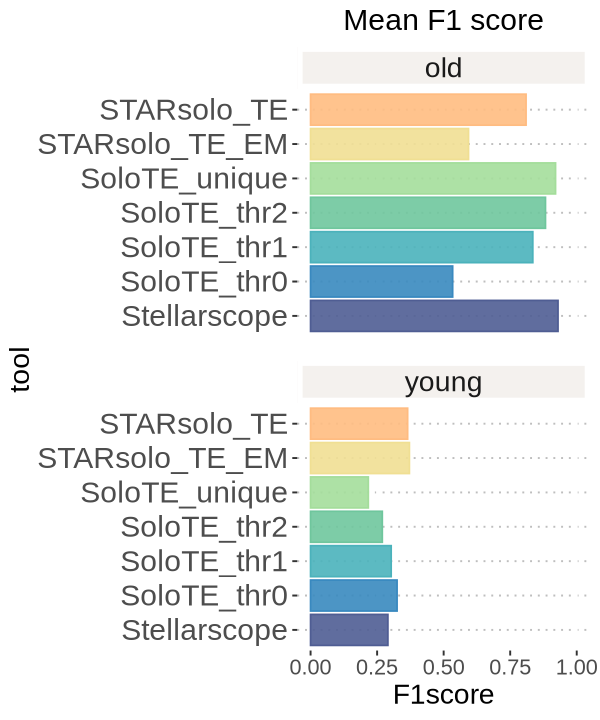

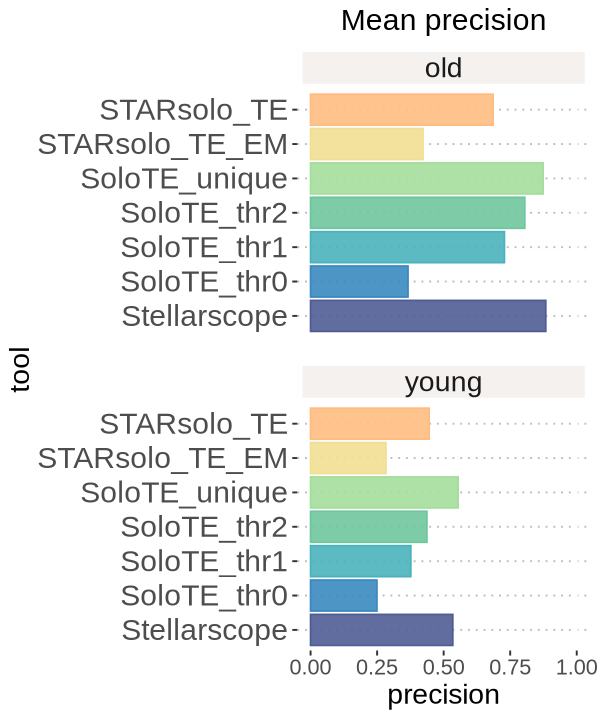

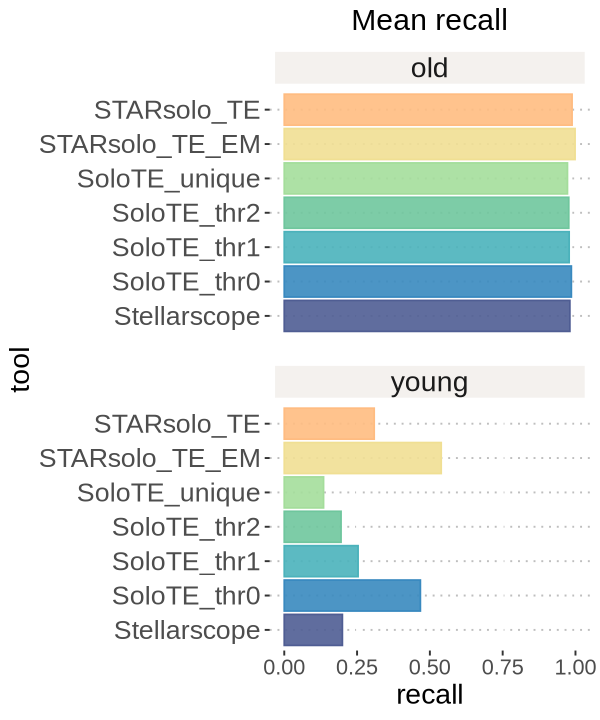

In [8]:
options(repr.plot.width=5, repr.plot.height=6)

ggplot(meanF1score_age_df, aes(x=F1score, y=tool, color=tool, fill=tool)) +
    facet_wrap(~age, ncol = 1) +
    geom_col(alpha = 0.9) +
    scale_color_manual(values=colorTools) +
    scale_fill_manual(values=colorTools) +
    theme_pubclean() + ggtitle(paste0("Mean F1 score")) +
    guides(fill="none", color="none") +
  xlim(c(0,1)) +
    theme(text=element_text(size=17), 
      plot.title = element_text(size=18, hjust=0.5), 
      plot.subtitle = element_text(size=18, hjust=0.5), 
      axis.text.y = element_text(size=18), 
      axis.text.x = element_text(size=13), 
      strip.text = element_text(size=17, hjust=0.5, vjust = 0.5),
      strip.background = element_rect(fill="#F4F1EE", linewidth = 3, color = "white"),
      panel.spacing = unit(1, "lines"))
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanF1_tool_byAge.png"), device="png", width=5, height=6)
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanF1_tool_byAge.pdf"), device="pdf", width=5, height=6)


ggplot(meanF1score_age_df, aes(x=precision, y=tool, color=tool, fill=tool)) +
    facet_wrap(~age, ncol = 1) +
    geom_col(alpha = 0.9) +
    scale_color_manual(values=colorTools) +
    scale_fill_manual(values=colorTools) +
    theme_pubclean() + ggtitle(paste0("Mean precision")) +
    guides(fill="none", color="none") +
  xlim(c(0,1)) +
    theme(text=element_text(size=17), 
      plot.title = element_text(size=18, hjust=0.5), 
      plot.subtitle = element_text(size=18, hjust=0.5), 
      axis.text.y = element_text(size=18), 
      axis.text.x = element_text(size=13), 
      strip.text = element_text(size=17, hjust=0.5, vjust = 0.5),
      strip.background = element_rect(fill="#F4F1EE", linewidth = 3, color = "white"),
      panel.spacing = unit(1, "lines"))
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanPrecision_tool_byAge.png"), device="png", width=5, height=6)
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanPrecision_tool_byAge.pdf"), device="pdf", width=5, height=6)

ggplot(meanF1score_age_df, aes(x=recall, y=tool, color=tool, fill=tool)) +
    facet_wrap(~age, ncol = 1) +
    geom_col(alpha = 0.9) +
    scale_color_manual(values=colorTools) +
    scale_fill_manual(values=colorTools) +
    theme_pubclean() + ggtitle(paste0("Mean recall")) +
    guides(fill="none", color="none") +
  xlim(c(0,1)) +
    theme(text=element_text(size=17), 
      plot.title = element_text(size=18, hjust=0.5), 
      plot.subtitle = element_text(size=18, hjust=0.5), 
      axis.text.y = element_text(size=16), 
      axis.text.x = element_text(size=13), 
      strip.text = element_text(size=17, hjust=0.5, vjust = 0.5),
      strip.background = element_rect(fill="#F4F1EE", linewidth = 3, color = "white"),
      panel.spacing = unit(1, "lines"))
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanRecall_tool_byAge.png"), device="png",width=5, height=6)
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanRecall_tool_byAge.pdf"), device="pdf",width=5, height=6)


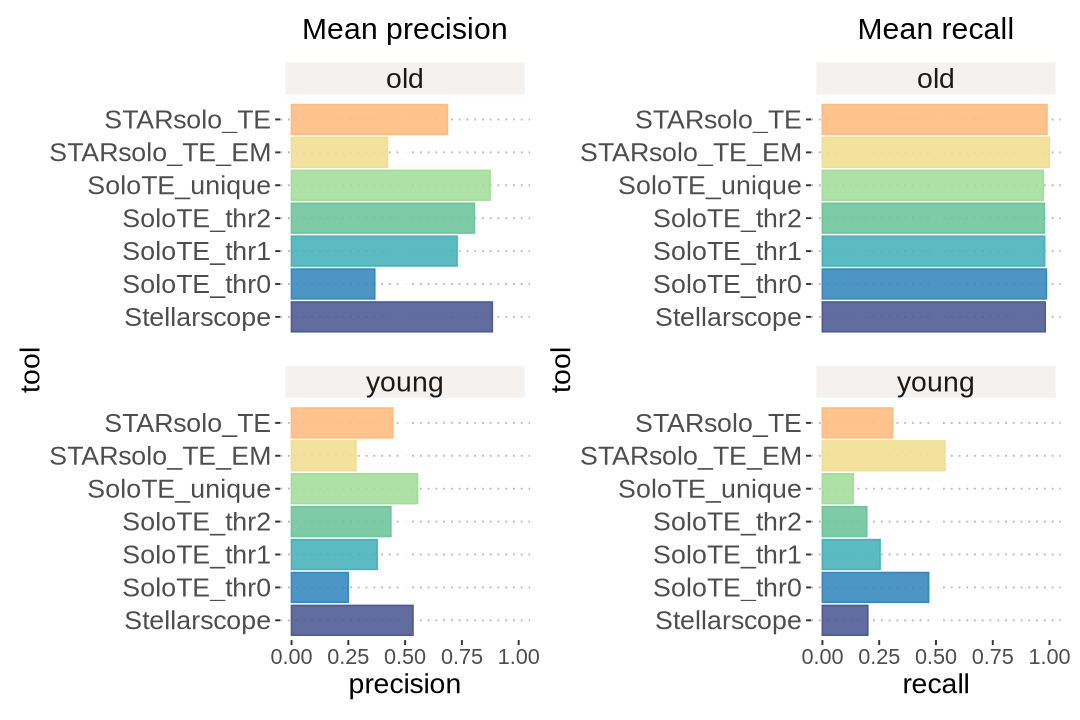

In [9]:
options(repr.plot.width=9, repr.plot.height=6)

precision_plot <- ggplot(meanF1score_age_df, aes(x=precision, y=tool, color=tool, fill=tool)) +
    facet_wrap(~age, ncol = 1) +
    geom_col(alpha = 0.9) +
    scale_color_manual(values=colorTools) +
    scale_fill_manual(values=colorTools) +
    theme_pubclean() + ggtitle(paste0("Mean precision")) +
    guides(fill="none", color="none") +
  xlim(c(0,1)) +
    theme(text=element_text(size=17), 
      plot.title = element_text(size=18, hjust=0.5), 
      plot.subtitle = element_text(size=18, hjust=0.5), 
      axis.text.y = element_text(size=16), 
      axis.text.x = element_text(size=13), 
      strip.text = element_text(size=17, hjust=0.5, vjust = 0.5),
      strip.background = element_rect(fill="#F4F1EE", linewidth = 3, color = "white"),
      panel.spacing = unit(1, "lines"))

recall_plot <- ggplot(meanF1score_age_df, aes(x=recall, y=tool, color=tool, fill=tool)) +
    facet_wrap(~age, ncol = 1) +
    geom_col(alpha = 0.9) +
    scale_color_manual(values=colorTools) +
    scale_fill_manual(values=colorTools) +
    theme_pubclean() + ggtitle(paste0("Mean recall")) +
    guides(fill="none", color="none") +
  xlim(c(0,1)) +
    theme(text=element_text(size=17), 
      plot.title = element_text(size=18, hjust=0.5), 
      plot.subtitle = element_text(size=18, hjust=0.5), 
      axis.text.y = element_text(size=16), 
      axis.text.x = element_text(size=13), 
      strip.text = element_text(size=17, hjust=0.5, vjust = 0.5),
      strip.background = element_rect(fill="#F4F1EE", linewidth = 3, color = "white"),
      panel.spacing = unit(1, "lines"))

precision_plot + recall_plot
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanPrecisionRecall_tool_byAge.png"), device="png", width=9, height=6)
ggsave(paste0("figures_",dataset_id,"_",sample,"/meanPrecisionRecall_tool_byAge.pdf"), device="pdf", width=9, height=6)
